# Exploratory Data Analysis (EDA) Final: Workforce Planning
Notebook ini berisi analisis mendalam terhadap dataset final yang sudah menyertakan fitur **Customer Base (CB)**. 
Tujuan EDA ini adalah untuk memvalidasi kualitas data, melihat distribusi, korelasi, dan mendeteksi anomali sebelum masuk ke tahap pemodelan.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('mobiledata_final_featured.csv')
features = [c for c in df.columns if c not in ['WOK', 'Jumlah Karyawan']]
target = 'Jumlah Karyawan'

df.head()

,WOK,Revenue Mobile,Luas WOK,Total Penduduk,Jumlah Gerai,Jumlah Mitra,Jumlah Kepala Keluarga,Jumlah Karyawan,CB,Total Kecamatan,HDI,PDRB,Gerai Density
0,Buleleng\r\nJembrana\r\nTabanan,224.0,2819.30,1538500.0,3.0,3.0,451239.0,1.0,312157.0,24.0,75.706691,4457252.793,0.001064
1,Kota Denpasar\r\nBadung,999.0,546.79,1273520.0,5.0,4.0,282968.0,22.0,1464489.0,10.0,84.638889,8840063.104,0.009144
2,Karang asem\r\nGianyar\r\nBangli\r\nKlungkung,323.0,2012.68,1472950.0,2.0,2.0,367348.0,2.0,100748.9,23.0,74.171553,4042507.380,0.000994
3,Sikka\r\nEnde,256.0,3215.84,633650.0,2.0,0.0,96262.0,2.0,350231.0,42.0,71.610939,1968897.393,0.000622
4,Alor\r\nFlores Timur\r\nLembata,256.0,5658.26,630320.0,2.0,0.0,104865.0,1.0,329401.0,46.0,69.645622,1600877.459,0.000353


## 1. Gambaran Umum Data
Melihat ukuran dataset, tipe data, dan statistik deskriptif dasar.

In [ ]:
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Statistik Deskriptif ---")
display(df.describe().round(2))

Jumlah Baris : 61
Jumlah Kolom : 13

--- Missing Values ---
WOK                       0
Revenue Mobile            0
Luas WOK                  0
Total Penduduk            0
Jumlah Gerai              0
Jumlah Mitra              0
Jumlah Kepala Keluarga    0
Jumlah Karyawan           0
CB                        0
Total Kecamatan           0
HDI                       0
PDRB                      0
Gerai Density             0
dtype: int64

--- Statistik Deskriptif ---


,Revenue Mobile,Luas WOK,Total Penduduk,Jumlah Gerai,Jumlah Mitra,Jumlah Kepala Keluarga,Jumlah Karyawan,CB,Total Kecamatan,HDI,PDRB,Gerai Density
count,61.00,61.00,61.00,61.00,61.00,61.00,61.00,61.00,61.00,61.00,61.00,61.00
mean,252.21,2549.45,1604959.52,1.95,14.97,453776.92,3.20,432604.26,29.75,75.36,4586643.79,0.00
std,207.01,2822.38,854136.60,1.16,25.34,262092.00,6.52,329286.16,16.16,4.35,3464640.20,0.01
min,14.00,33.23,201760.00,0.00,0.00,52951.00,1.00,24292.00,3.00,66.84,1496262.85,0.00
25%,131.00,1022.69,1015769.00,1.00,0.00,255515.00,1.00,222257.00,18.00,73.02,2670625.00,0.00
50%,207.00,1769.62,1363601.00,2.00,6.00,393794.00,1.00,361359.00,26.00,75.07,3288691.67,0.00
75%,294.00,2819.30,2027379.00,3.00,17.00,618674.00,3.00,530545.00,40.00,77.06,5569384.89,0.00
max,1042.00,15616.97,3735740.00,5.00,140.00,1103090.00,43.00,1710672.00,77.00,86.35,22030991.67,0.03


## 2. Distribusi Target Variabel (Jumlah Karyawan)
Melihat apakah distribusi target kita normal atau *Right-Skewed* (condong ke kanan akibat adanya WOK metropolitan).

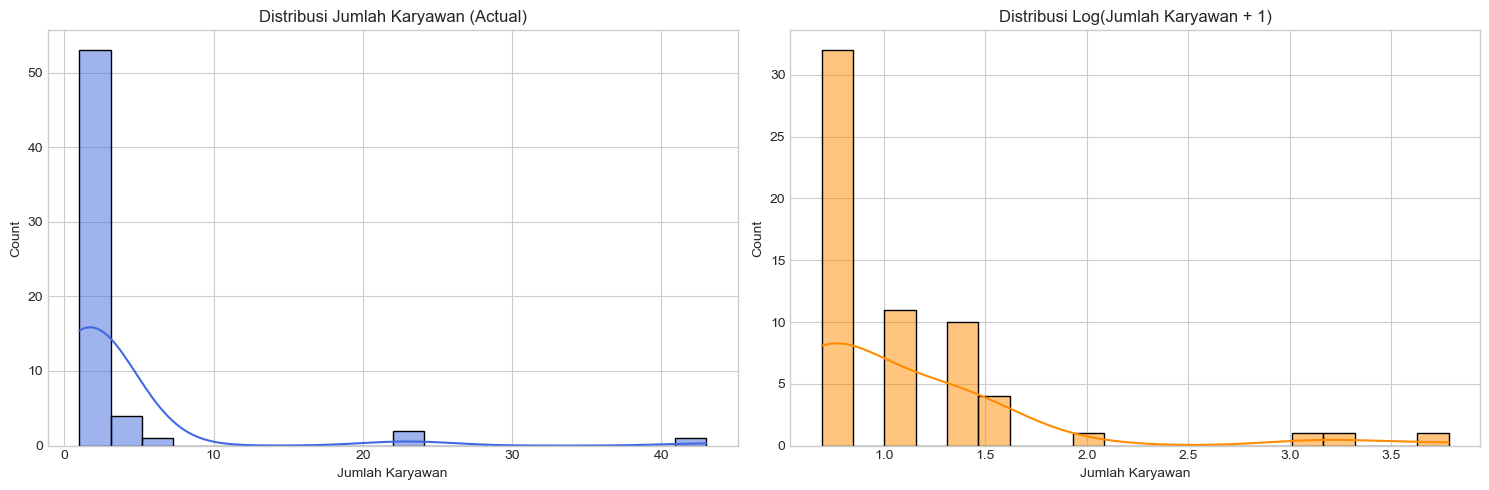

Skewness Asli: 4.87 (Sangat menceng kanan)
Skewness Log : 2.57 (Lebih mendekati normal)


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
sns.histplot(df[target], kde=True, bins=20, color='royalblue', ax=ax[0])
ax[0].set_title('Distribusi Jumlah Karyawan (Actual)')

# Log-Transformed Histogram
sns.histplot(np.log1p(df[target]), kde=True, bins=20, color='darkorange', ax=ax[1])
ax[1].set_title('Distribusi Log(Jumlah Karyawan + 1)')

plt.tight_layout()
plt.show()

print(f"Skewness Asli: {df[target].skew():.2f} (Sangat menceng kanan)")
print(f"Skewness Log : {np.log1p(df[target]).skew():.2f} (Lebih mendekati normal)")

## 3. Distribusi Tiap Fitur
Melihat sebaran nilai pada setiap fitur (variabel independen).

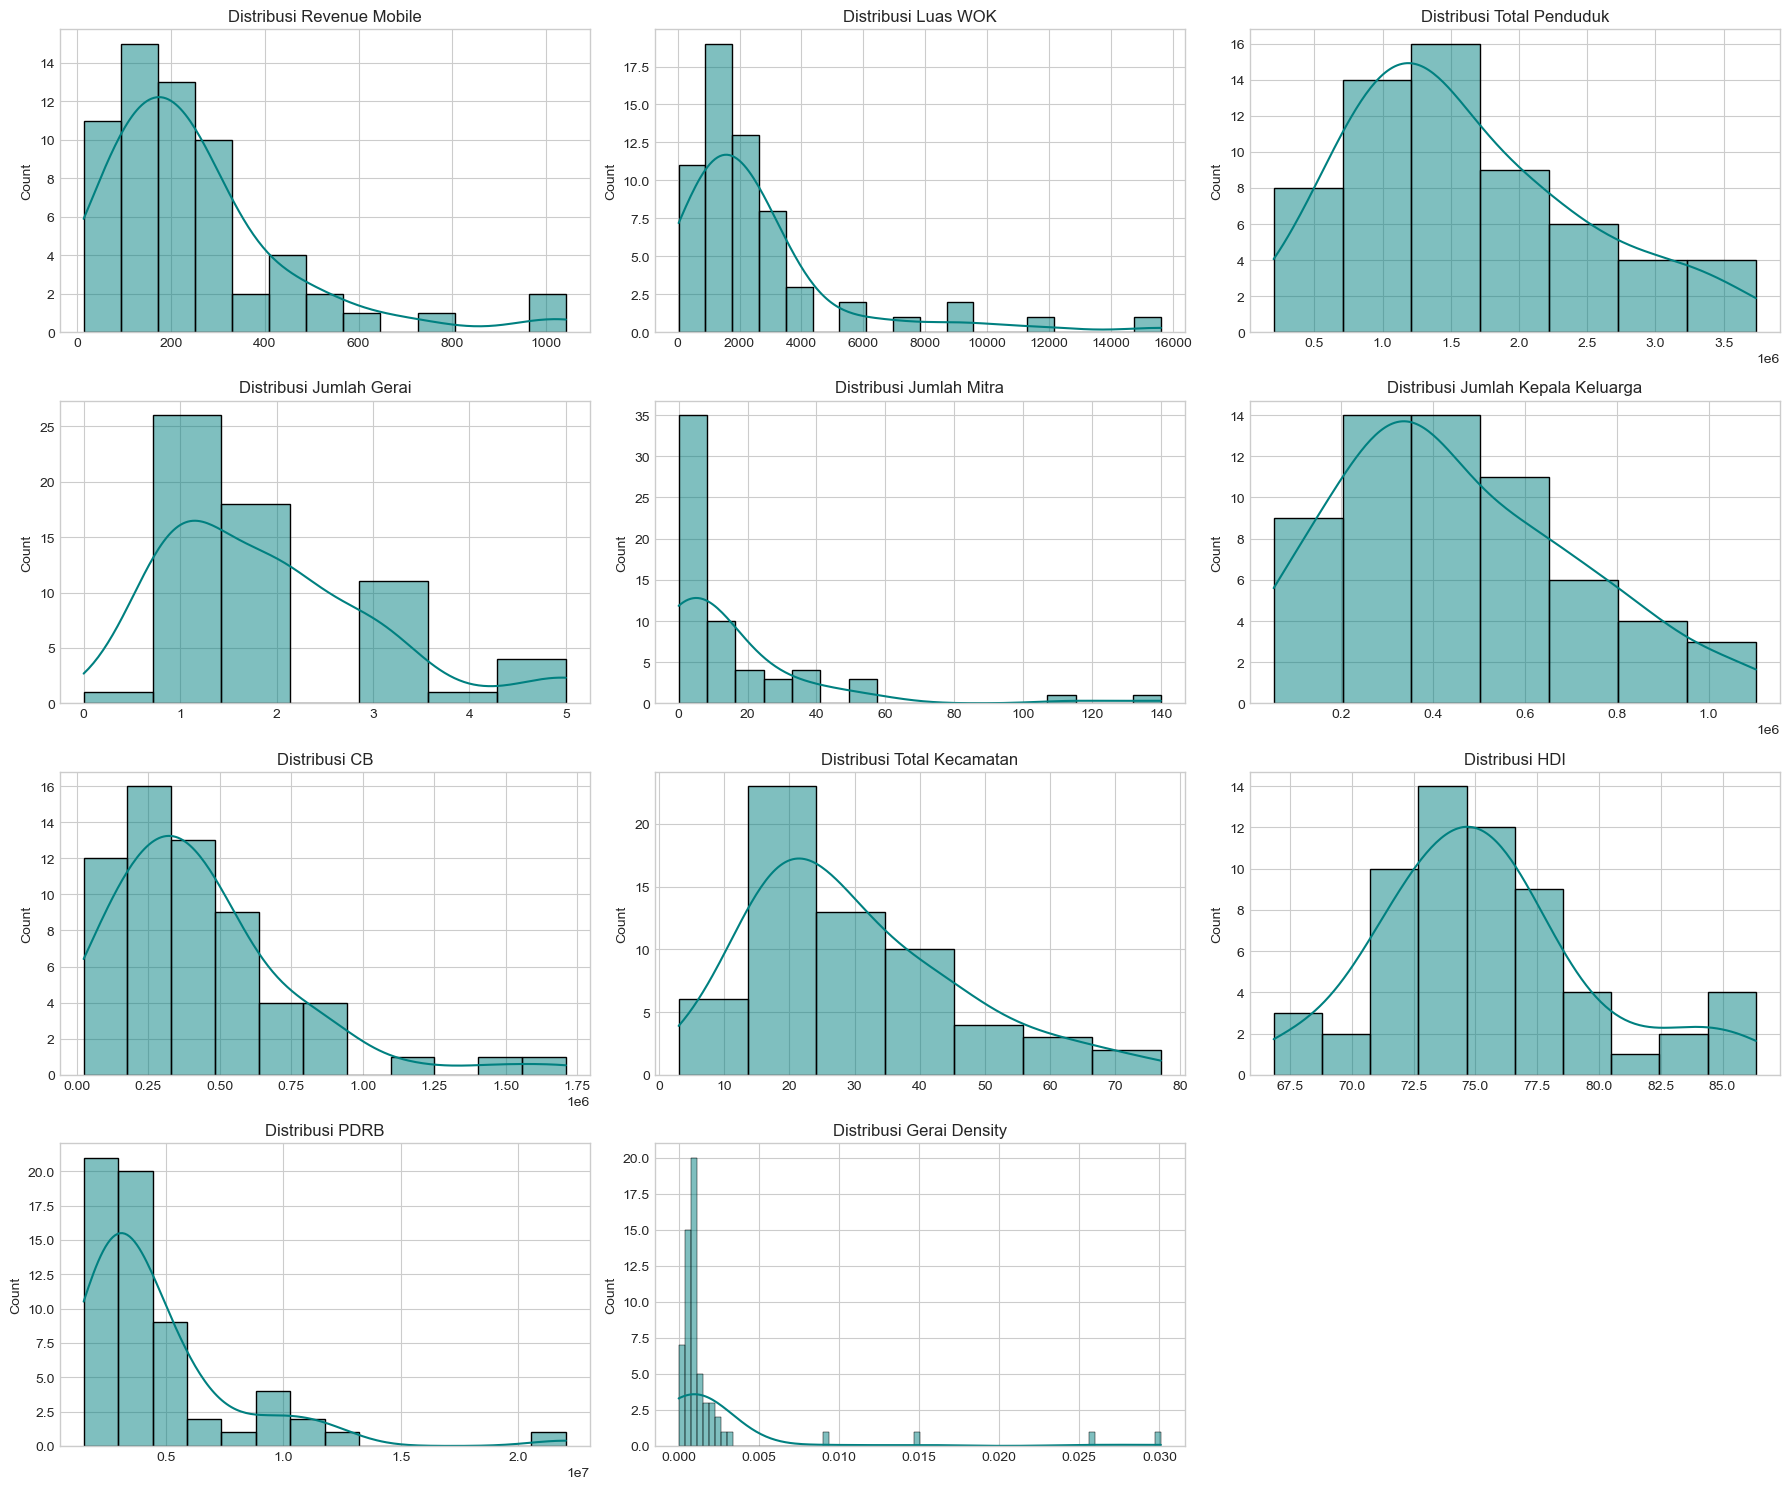

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('')

# Hapus plot kosong jika ada
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

## 4. Deteksi Outlier (Boxplot)
Menggunakan Boxplot untuk melihat seberapa banyak kota-kota anomali (pencilan) di setiap metrik.

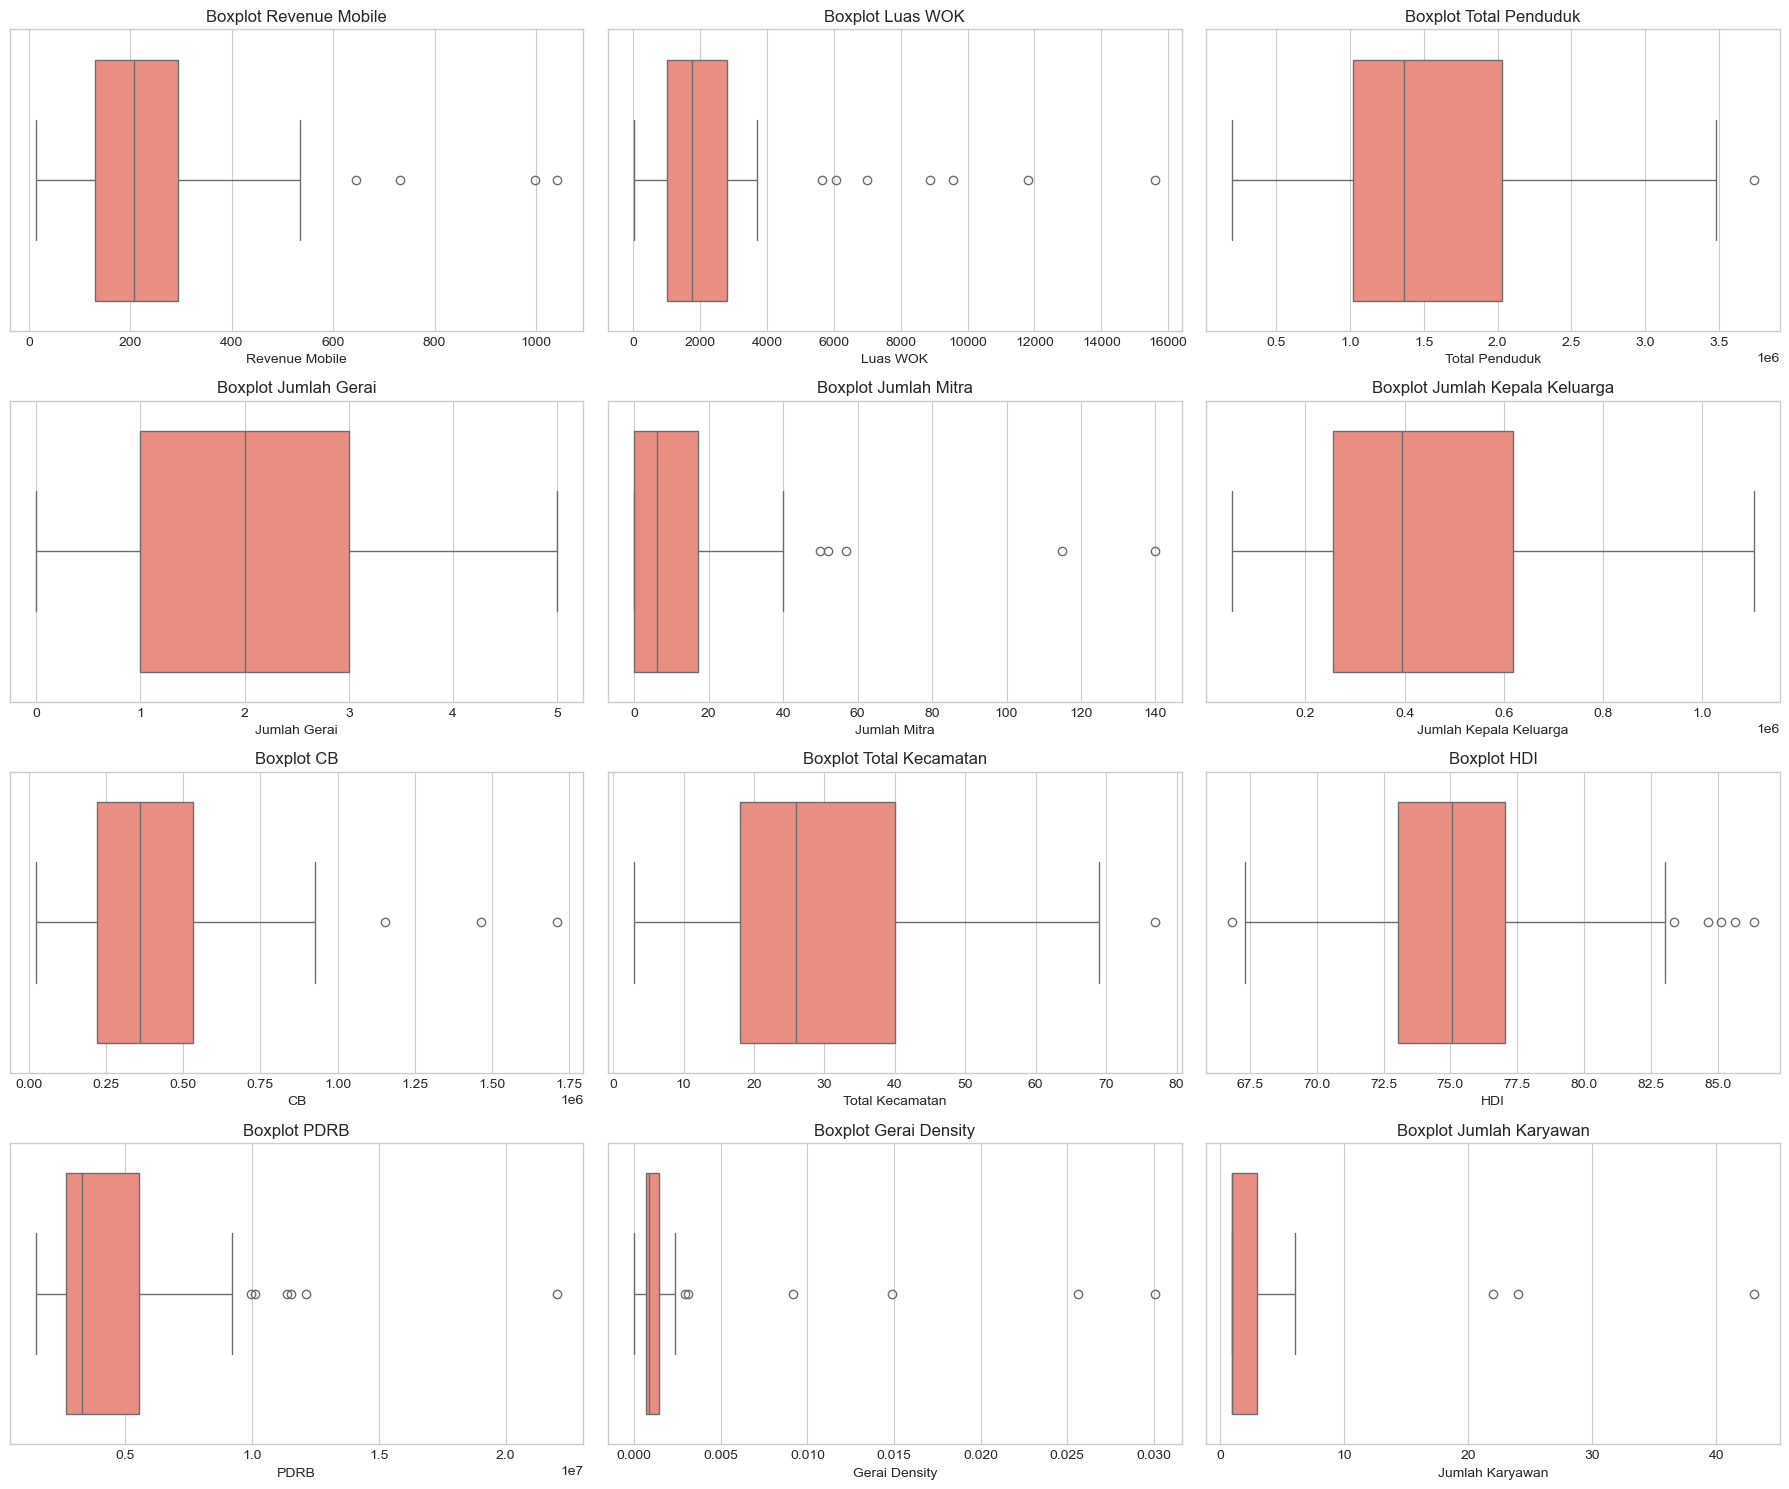

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(features + [target]):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot {col}')

# Hapus plot kosong
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

## 5. Scatter Plot: Fitur vs Jumlah Karyawan
Melihat secara visual hubungan linear (atau eksponensial) antara fitur dengan target.

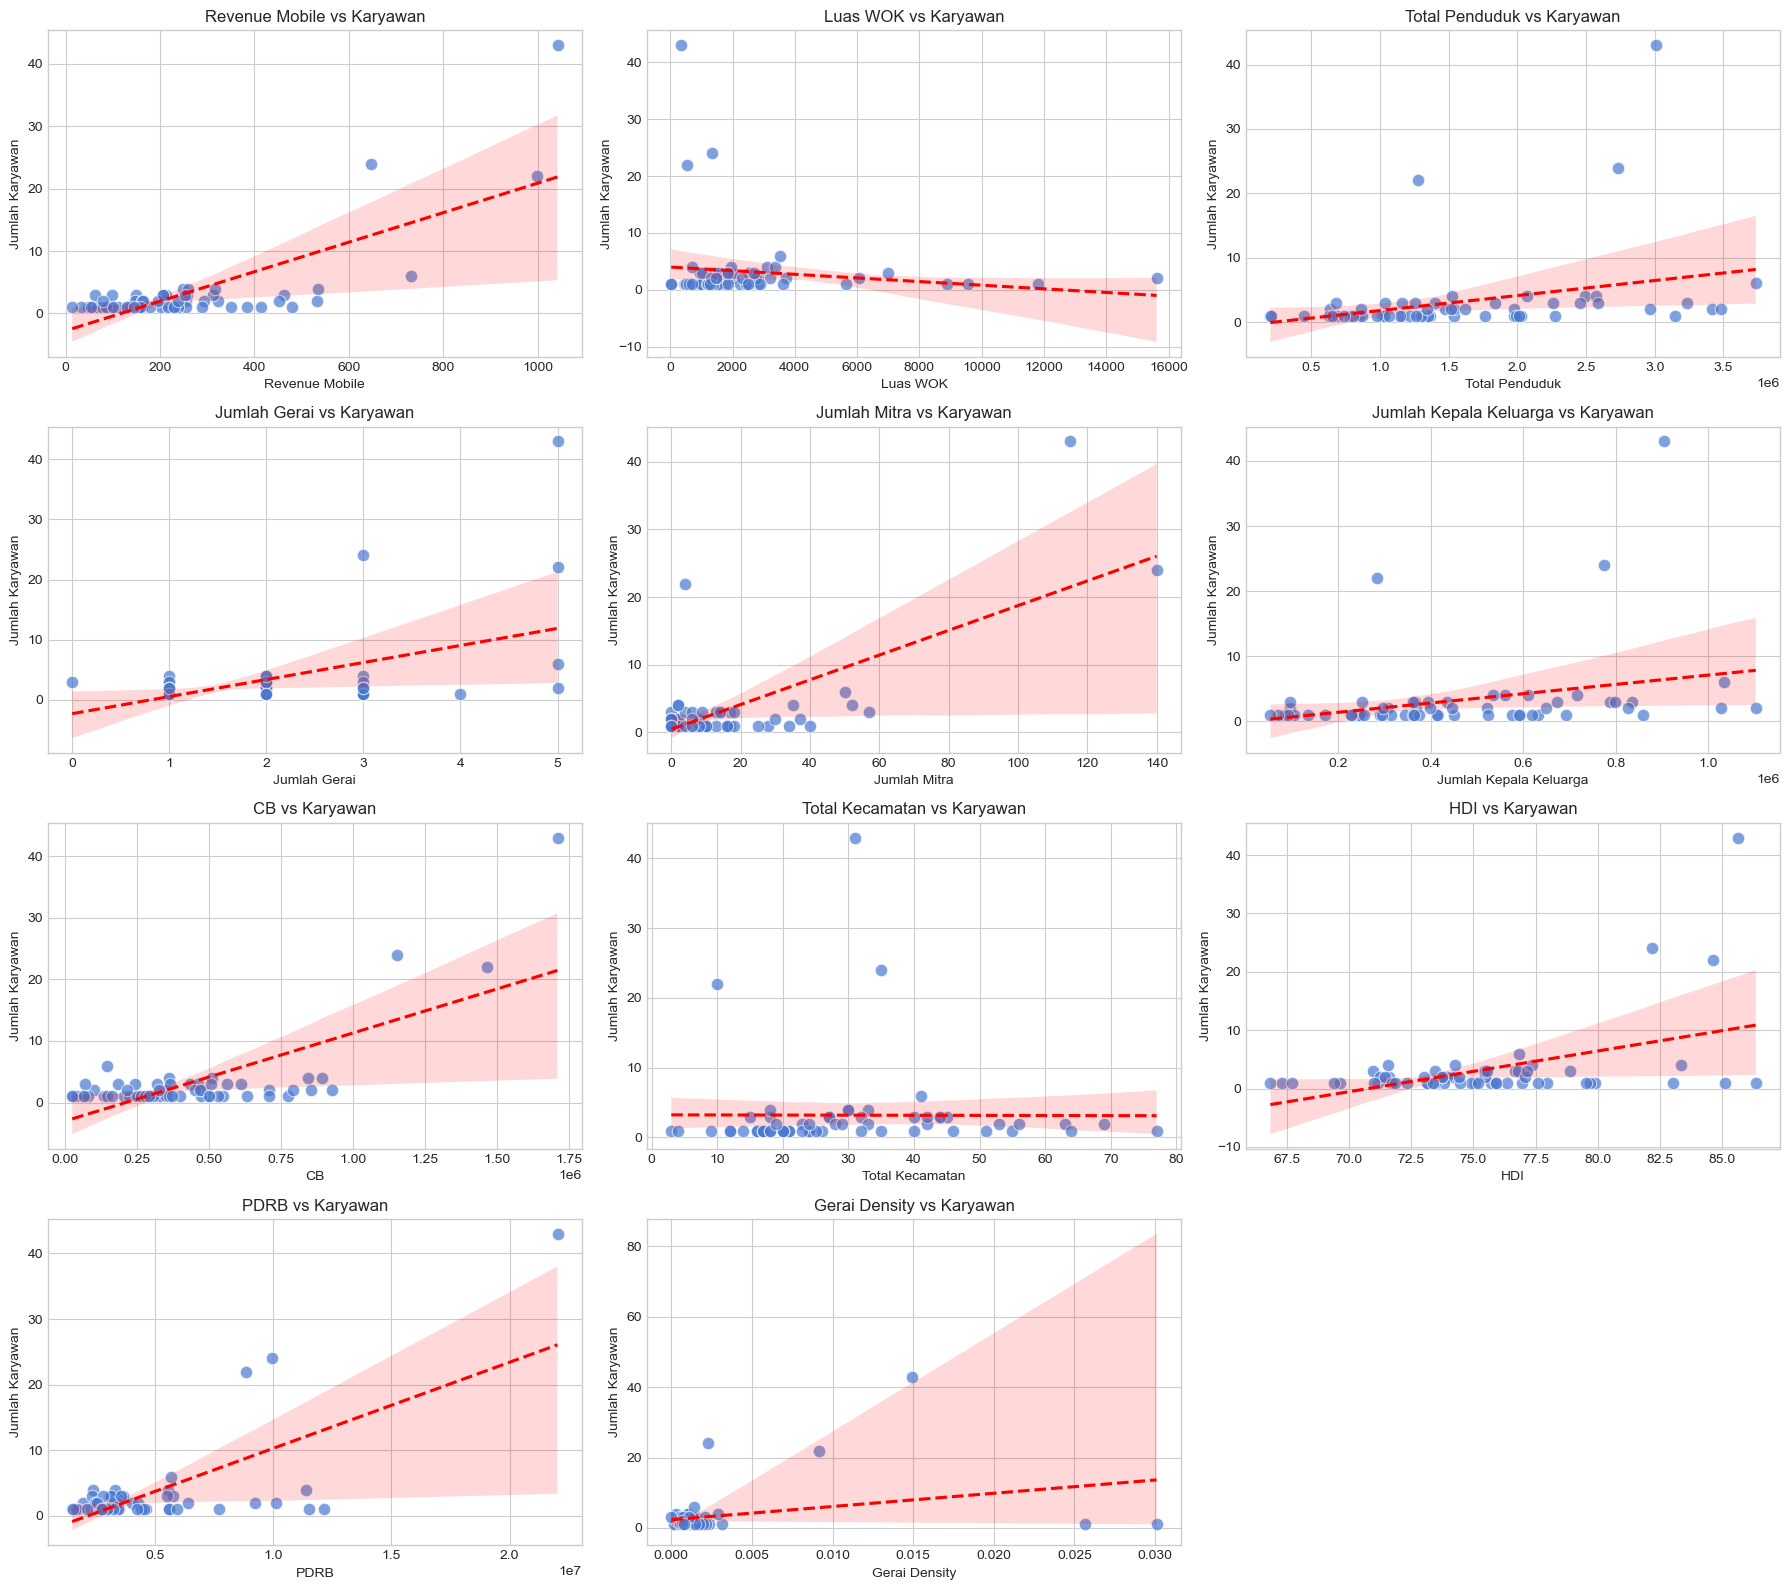

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(x=df[col], y=df[target], ax=axes[i], alpha=0.7, edgecolor='w', s=80)
    
    # Tambahkan garis tren (regresi linear sederhana)
    sns.regplot(x=df[col], y=df[target], ax=axes[i], scatter=False, color='red', line_kws={'linestyle':'--'})
    
    axes[i].set_title(f'{col} vs Karyawan')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

## 6. Analisis Korelasi (Pearson & Spearman)
*   **Pearson**: Mengukur hubungan linear.
*   **Spearman**: Mengukur hubungan monotonik (berdasarkan ranking). Sangat cocok untuk data yang memiliki *outlier* ekstrem atau tidak berdistribusi normal.

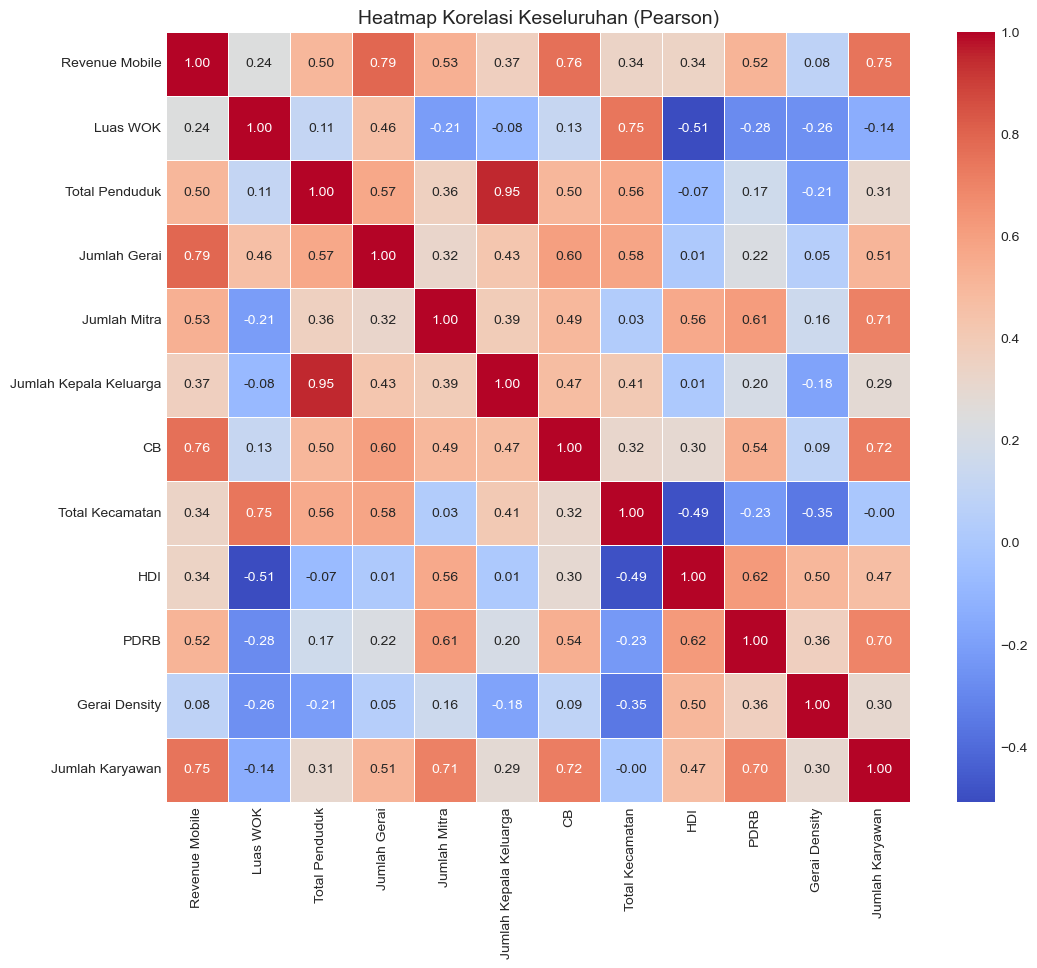

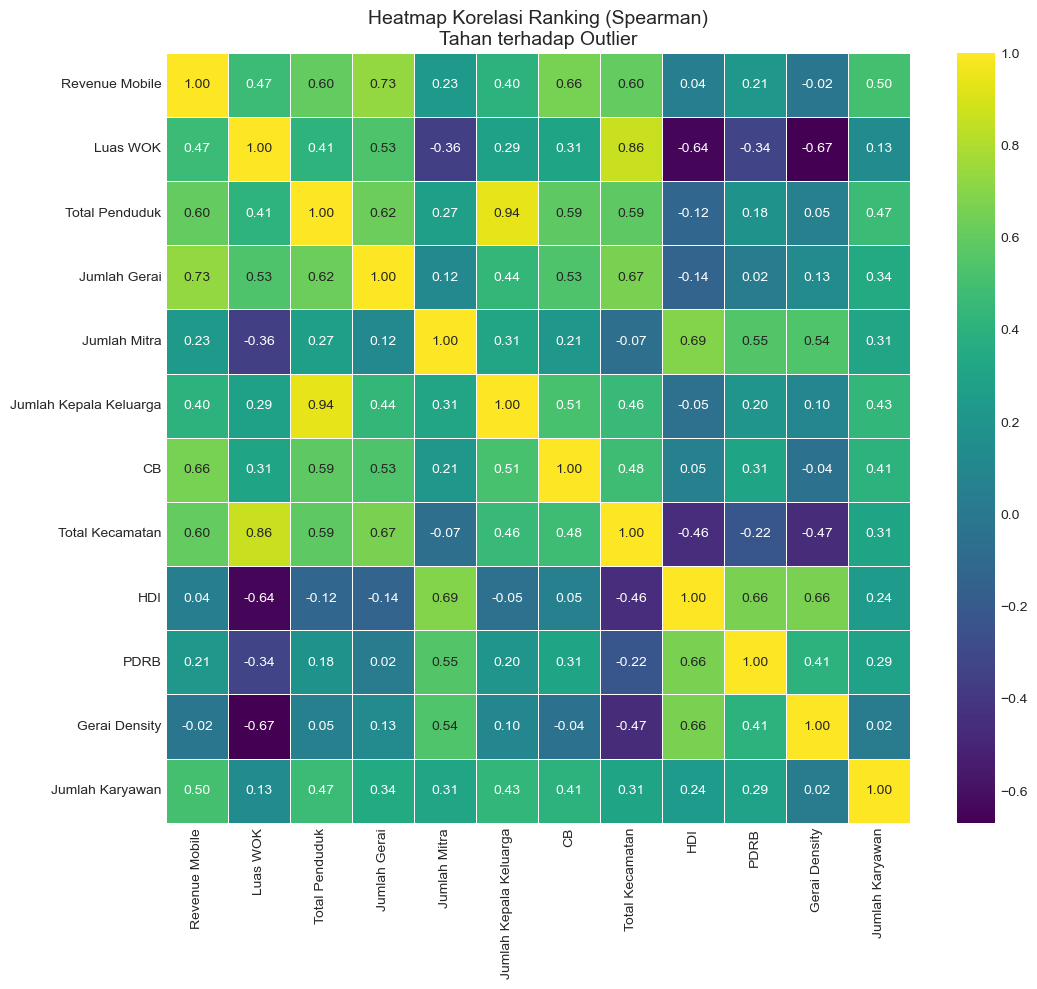

Top Fitur Berdasarkan Korelasi Spearman ke Target:
Revenue Mobile            0.500370
Total Penduduk            0.471131
Jumlah Kepala Keluarga    0.430149
CB                        0.405071
Jumlah Gerai              0.342234
Jumlah Mitra              0.311129
Total Kecamatan           0.307741
PDRB                      0.294899
HDI                       0.237492
Luas WOK                  0.130279
Gerai Density             0.022202
Name: Jumlah Karyawan, dtype: float64


In [ ]:
# Heatmap Pearson
plt.figure(figsize=(12, 10))
corr_pearson = df[features + [target]].corr(method='pearson')
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Keseluruhan (Pearson)', fontsize=14)
plt.show()

# Heatmap Spearman
plt.figure(figsize=(12, 10))
corr_spearman = df[features + [target]].corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Ranking (Spearman)\nTahan terhadap Outlier', fontsize=14)
plt.show()

print("Top Fitur Berdasarkan Korelasi Spearman ke Target:")
print(corr_spearman[target].sort_values(ascending=False)[1:])

## 7. Deteksi Multikolinearitas (VIF)
*Variance Inflation Factor* (VIF) digunakan untuk mendeteksi apakah ada fitur yang sangat redundan (saling menjelaskan satu sama lain).
*   **VIF < 5**: Aman.
*   **VIF > 10**: Multikolinearitas tinggi (pertimbangkan untuk dihapus/digabung).

In [ ]:
def calc_vif(X):
    # Tambahkan konstan untuk perhitungan VIF
    from statsmodels.tools.tools import add_constant
    X_vif = add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["Fitur"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    return vif_data[vif_data["Fitur"] != 'const'].sort_values(by="VIF", ascending=False)

vif_df = calc_vif(df[features])
display(vif_df.style.background_gradient(cmap='Reds'))

print("\nCatatan:")
print("Jika 'Total Penduduk' dan 'Jumlah Kepala Keluarga' memiliki VIF sangat tinggi (>> 10),")
print("itu membuktikan bahwa mereka saling tumpang tindih (redundan) dan memicu multikolinearitas.")

,Fitur,VIF
3,Total Penduduk,30.870567
6,Jumlah Kepala Keluarga,27.798501
1,Revenue Mobile,8.719710
8,Total Kecamatan,5.675724
4,Jumlah Gerai,4.703041
2,Luas WOK,4.583510
9,HDI,3.617743
7,CB,3.418614
10,PDRB,2.661688
5,Jumlah Mitra,2.455219



Catatan:
Jika 'Total Penduduk' dan 'Jumlah Kepala Keluarga' memiliki VIF sangat tinggi (>> 10),
itu membuktikan bahwa mereka saling tumpang tindih (redundan) dan memicu multikolinearitas.
